In [1]:
import pandas as pd
monthly_complete = pd.read_csv("monthly_data.csv")

In [2]:
"""
A crime risk index is a single score that answers:
How risky a particular city is based on crime level, direction and stability?

We are going to use the following features after normalizing them between 0 and 1:
1) Crime Rate
2) Volatility
3) Trend Slope
"""
#Calculating and normalizing crime rate
crime_mean = (
    monthly_complete
    .groupby("City")["Crime_Count"]
    .mean()
    .reset_index(name = "Mean_Crime")
)

min_val = crime_mean["Mean_Crime"].min()
max_val = crime_mean["Mean_Crime"].max()

crime_mean["Normalized_Crime"] = (
    (crime_mean["Mean_Crime"] - min_val) /
    (max_val - min_val)
)

print(crime_mean)

             City  Mean_Crime  Normalized_Crime
0            Agra   13.890909          0.087402
1       Ahmedabad   33.036364          0.294685
2       Bangalore   65.236364          0.643307
3          Bhopal   12.545455          0.072835
4         Chennai   45.327273          0.427756
5           Delhi   98.181818          1.000000
6       Faridabad    6.436364          0.006693
7       Ghaziabad   12.800000          0.075591
8       Hyderabad   52.381818          0.504134
9          Indore   12.709091          0.074606
10         Jaipur   26.890909          0.228150
11         Kalyan    6.454545          0.006890
12         Kanpur   20.218182          0.155906
13        Kolkata   45.781818          0.432677
14        Lucknow   26.472727          0.223622
15       Ludhiana   13.836364          0.086811
16         Meerut    7.181818          0.014764
17         Mumbai   80.272727          0.806102
18         Nagpur   19.145455          0.144291
19         Nashik    6.654545          0

In [3]:
#Calculating and normalizing volatility
volatility = (
    monthly_complete
    .groupby("City")["Crime_Count"]
    .aggregate(["mean", "std"])
    .reset_index()
)

volatility["Volatility"] = volatility["std"] / volatility["mean"]
volatility


,City,mean,std,Volatility
0,Agra,13.890909,3.798990,0.273487
1,Ahmedabad,33.036364,5.567643,0.168531
2,Bangalore,65.236364,7.290185,0.111750
3,Bhopal,12.545455,3.457778,0.275620
4,Chennai,45.327273,6.842283,0.150953
5,Delhi,98.181818,9.722237,0.099023
6,Faridabad,6.436364,2.183809,0.339292
7,Ghaziabad,12.800000,3.663635,0.286221
8,Hyderabad,52.381818,7.260984,0.138616
9,Indore,12.709091,3.541671,0.278672


In [4]:
#Extracting trend slopes
trend_slopes = (
    monthly_complete[["City", "Trend_Slope"]]
    .drop_duplicates()
    .reset_index(drop = True)
)

#Merging all the required values back into one dataframe
city_features = (
    crime_mean[["City", "Normalized_Crime"]]
    .merge(volatility[["City", "Volatility"]], on = "City")
    .merge(trend_slopes, on = "City")
)



In [5]:
min_slope = city_features["Trend_Slope"].min()
max_slope = city_features["Trend_Slope"].max()

"""
Monthly data was used for temporal analysis and forecasting, while city-level aggregates 
such as volatility and normalized crime were computed separately to avoid data duplication
and aggregation bias
"""

city_features["Trend_Score"] = (
    (city_features["Trend_Slope"] - min_slope) /
    (max_slope - min_slope)
)

city_features.describe()

,Normalized_Crime,Volatility,Trend_Slope,Trend_Score
count,29.000000,29.000000,29.000000,29.000000
mean,0.209612,0.252088,-0.000119,0.398208
std,0.257795,0.100448,0.035573,0.207682
min,0.000000,0.099023,-0.068326,0.000000
25%,0.014764,0.168531,-0.013564,0.319714
50%,0.086811,0.273487,0.000144,0.399747
75%,0.294685,0.302237,0.019625,0.513479
max,1.000000,0.427148,0.102958,1.000000


In [6]:
"""
Crime Risk Index =
  0.5 * Normalized Crime Level
+ 0.3 * Trend Score
+ 0.2 * Volatility Score

Why?
Because crime level matters the most while calculating risk
Trend score matters second because it highlights improving vs worsening conditions
Volatility matters but should not dominate 
"""

city_features["Crime_Risk_Index"] = (
    city_features["Normalized_Crime"] * 0.5 +
    city_features["Trend_Score"] * 0.3 + 
    city_features["Volatility"] * 0.2
)

print(city_features[["City", "Crime_Risk_Index"]])

             City  Crime_Risk_Index
0            Agra          0.216048
1       Ahmedabad          0.191664
2       Bangalore          0.488064
3          Bhopal          0.258980
4         Chennai          0.352746
5           Delhi          0.547227
6       Faridabad          0.225249
7       Ghaziabad          0.206244
8       Hyderabad          0.287751
9          Indore          0.154579
10         Jaipur          0.149504
11         Kalyan          0.172649
12         Kanpur          0.239690
13        Kolkata          0.338541
14        Lucknow          0.275277
15       Ludhiana          0.263686
16         Meerut          0.228658
17         Mumbai          0.724742
18         Nagpur          0.295939
19         Nashik          0.202843
20          Patna          0.249821
21           Pune          0.405840
22         Rajkot          0.253901
23       Srinagar          0.187659
24          Surat          0.262815
25          Thane          0.175516
26       Varanasi          0

In [7]:
#Helps categorize cities based on low, moderate, high and critical risk levels

def classify_risk(score):
    if score < 0.25:
        return "Low"
    elif score < 0.5:
        return "Moderate"
    elif score < 0.75:
        return "High"
    else:
        return "Critical"

city_features["Risk_Level"] = city_features["Crime_Risk_Index"].apply(classify_risk)
city_features = (
    city_features
    .sort_values("Crime_Risk_Index", ascending=False)
    .reset_index(drop = True)
)

print(city_features[["City", "Crime_Risk_Index", "Risk_Level"]])

             City  Crime_Risk_Index Risk_Level
0          Mumbai          0.724742       High
1           Delhi          0.547227       High
2       Bangalore          0.488064   Moderate
3            Pune          0.405840   Moderate
4         Chennai          0.352746   Moderate
5         Kolkata          0.338541   Moderate
6          Nagpur          0.295939   Moderate
7       Hyderabad          0.287751   Moderate
8         Lucknow          0.275277   Moderate
9        Ludhiana          0.263686   Moderate
10          Surat          0.262815   Moderate
11         Bhopal          0.258980   Moderate
12         Rajkot          0.253901   Moderate
13          Patna          0.249821        Low
14         Kanpur          0.239690        Low
15  Visakhapatnam          0.237158        Low
16         Meerut          0.228658        Low
17      Faridabad          0.225249        Low
18           Agra          0.216048        Low
19          Vasai          0.206845        Low
20      Ghazi

C:\Users\abum0\AppData\Local\Temp\ipykernel_16968\2441112532.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


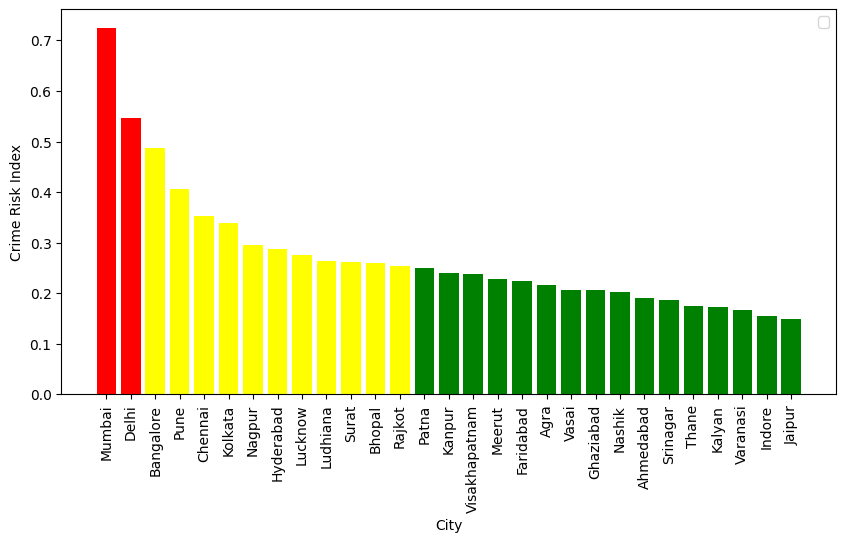

In [ ]:
import matplotlib.pyplot as plt

"""
The Crime Risk Index ranking indicates that Mumbai exhibits the highest combined risk
considering crime level, trend direction and volatility
"""

colors = {
    "Low": "green",
    "Moderate": "yellow",
    "High": "red"
}

bar_colors = city_features["Risk_Level"].map(colors)

plt.figure(figsize=(10, 5))
plt.bar(city_features["City"], city_features["Crime_Risk_Index"], color = bar_colors)
plt.xticks(rotation = 90)
plt.xlabel("City")
plt.ylabel("Crime Risk Index")
#plt.title("Crime Risk Index by City (Categorized by Risk Level)")
plt.show()

This index supports comparative risk monitoring based on historical trends

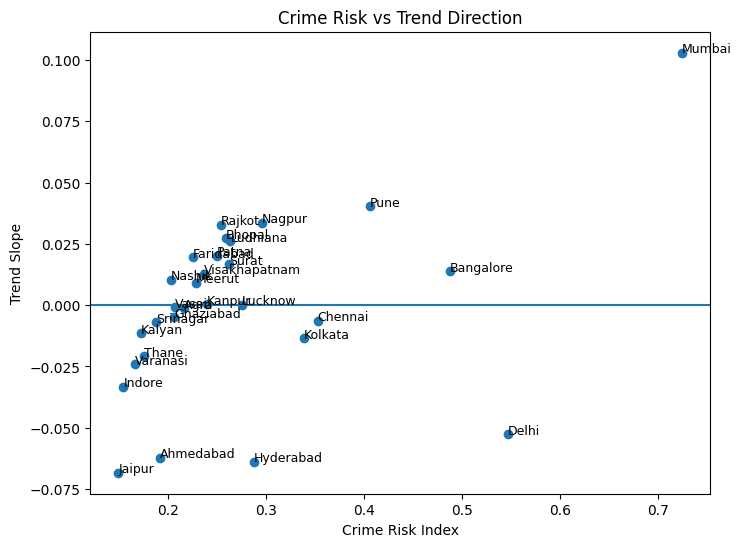

In [9]:
plt.figure(figsize = (8, 6))
plt.scatter(city_features["Crime_Risk_Index"], city_features["Trend_Slope"])

for _, row in city_features.iterrows():
    plt.text(row["Crime_Risk_Index"], row["Trend_Slope"], row["City"], fontsize = 9)

plt.axhline(0)
plt.xlabel("Crime Risk Index")
plt.ylabel("Trend Slope")
plt.title("Crime Risk vs Trend Direction")
plt.show()

Mumbai shows overall high baseline crime along with a positive trend slope, resulting in elevated overall risk.
Delhi does rank second in the crime risk index but seems to have a negative trend slope, indicating that
the situation might be improving.

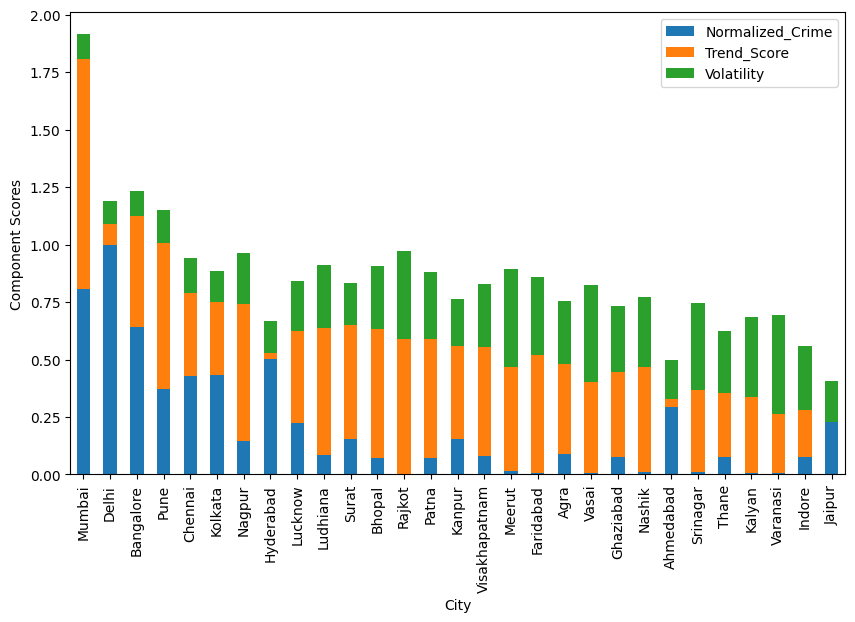

In [12]:
"""
Let's see how each component of the crime risk index, normalized crime rate,
trend slope and volatility, is contributing to each individual city.
"""

components = city_features[["Normalized_Crime", "Trend_Score", "Volatility"]]
components.index = city_features["City"]

components.plot(kind = "bar", stacked = True, figsize = (10, 6))
#plt.title("Risk Index Component Distribution by City")
plt.ylabel("Component Scores")
plt.xticks(rotation = 90)
plt.show()